In [ ]:
# packages
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Fluctuator, Trajectory

In [2]:
# mean and std data
anka_mean = {'ball_speed': 71.5, 'launch_angle': 11, 'spin_rate': 2100, 'spin_axis': -0.5, 'orientation': 0}
anka_std = {'ball_speed': 1, 'launch_angle': 0.9, 'spin_rate': 700, 'spin_axis': 1, 'orientation': 1.8}

parameters = ['ball_speed', 'launch_angle', 'spin_rate', 'spin_axis', 'orientation']
param_names = [r'Initial velocity $v_0$', r'Launch Angle $\alpha_0$', r'Spin Rate $\omega_0$', r'Spin Axis $\phi_0$', r'Orientation $\theta$']

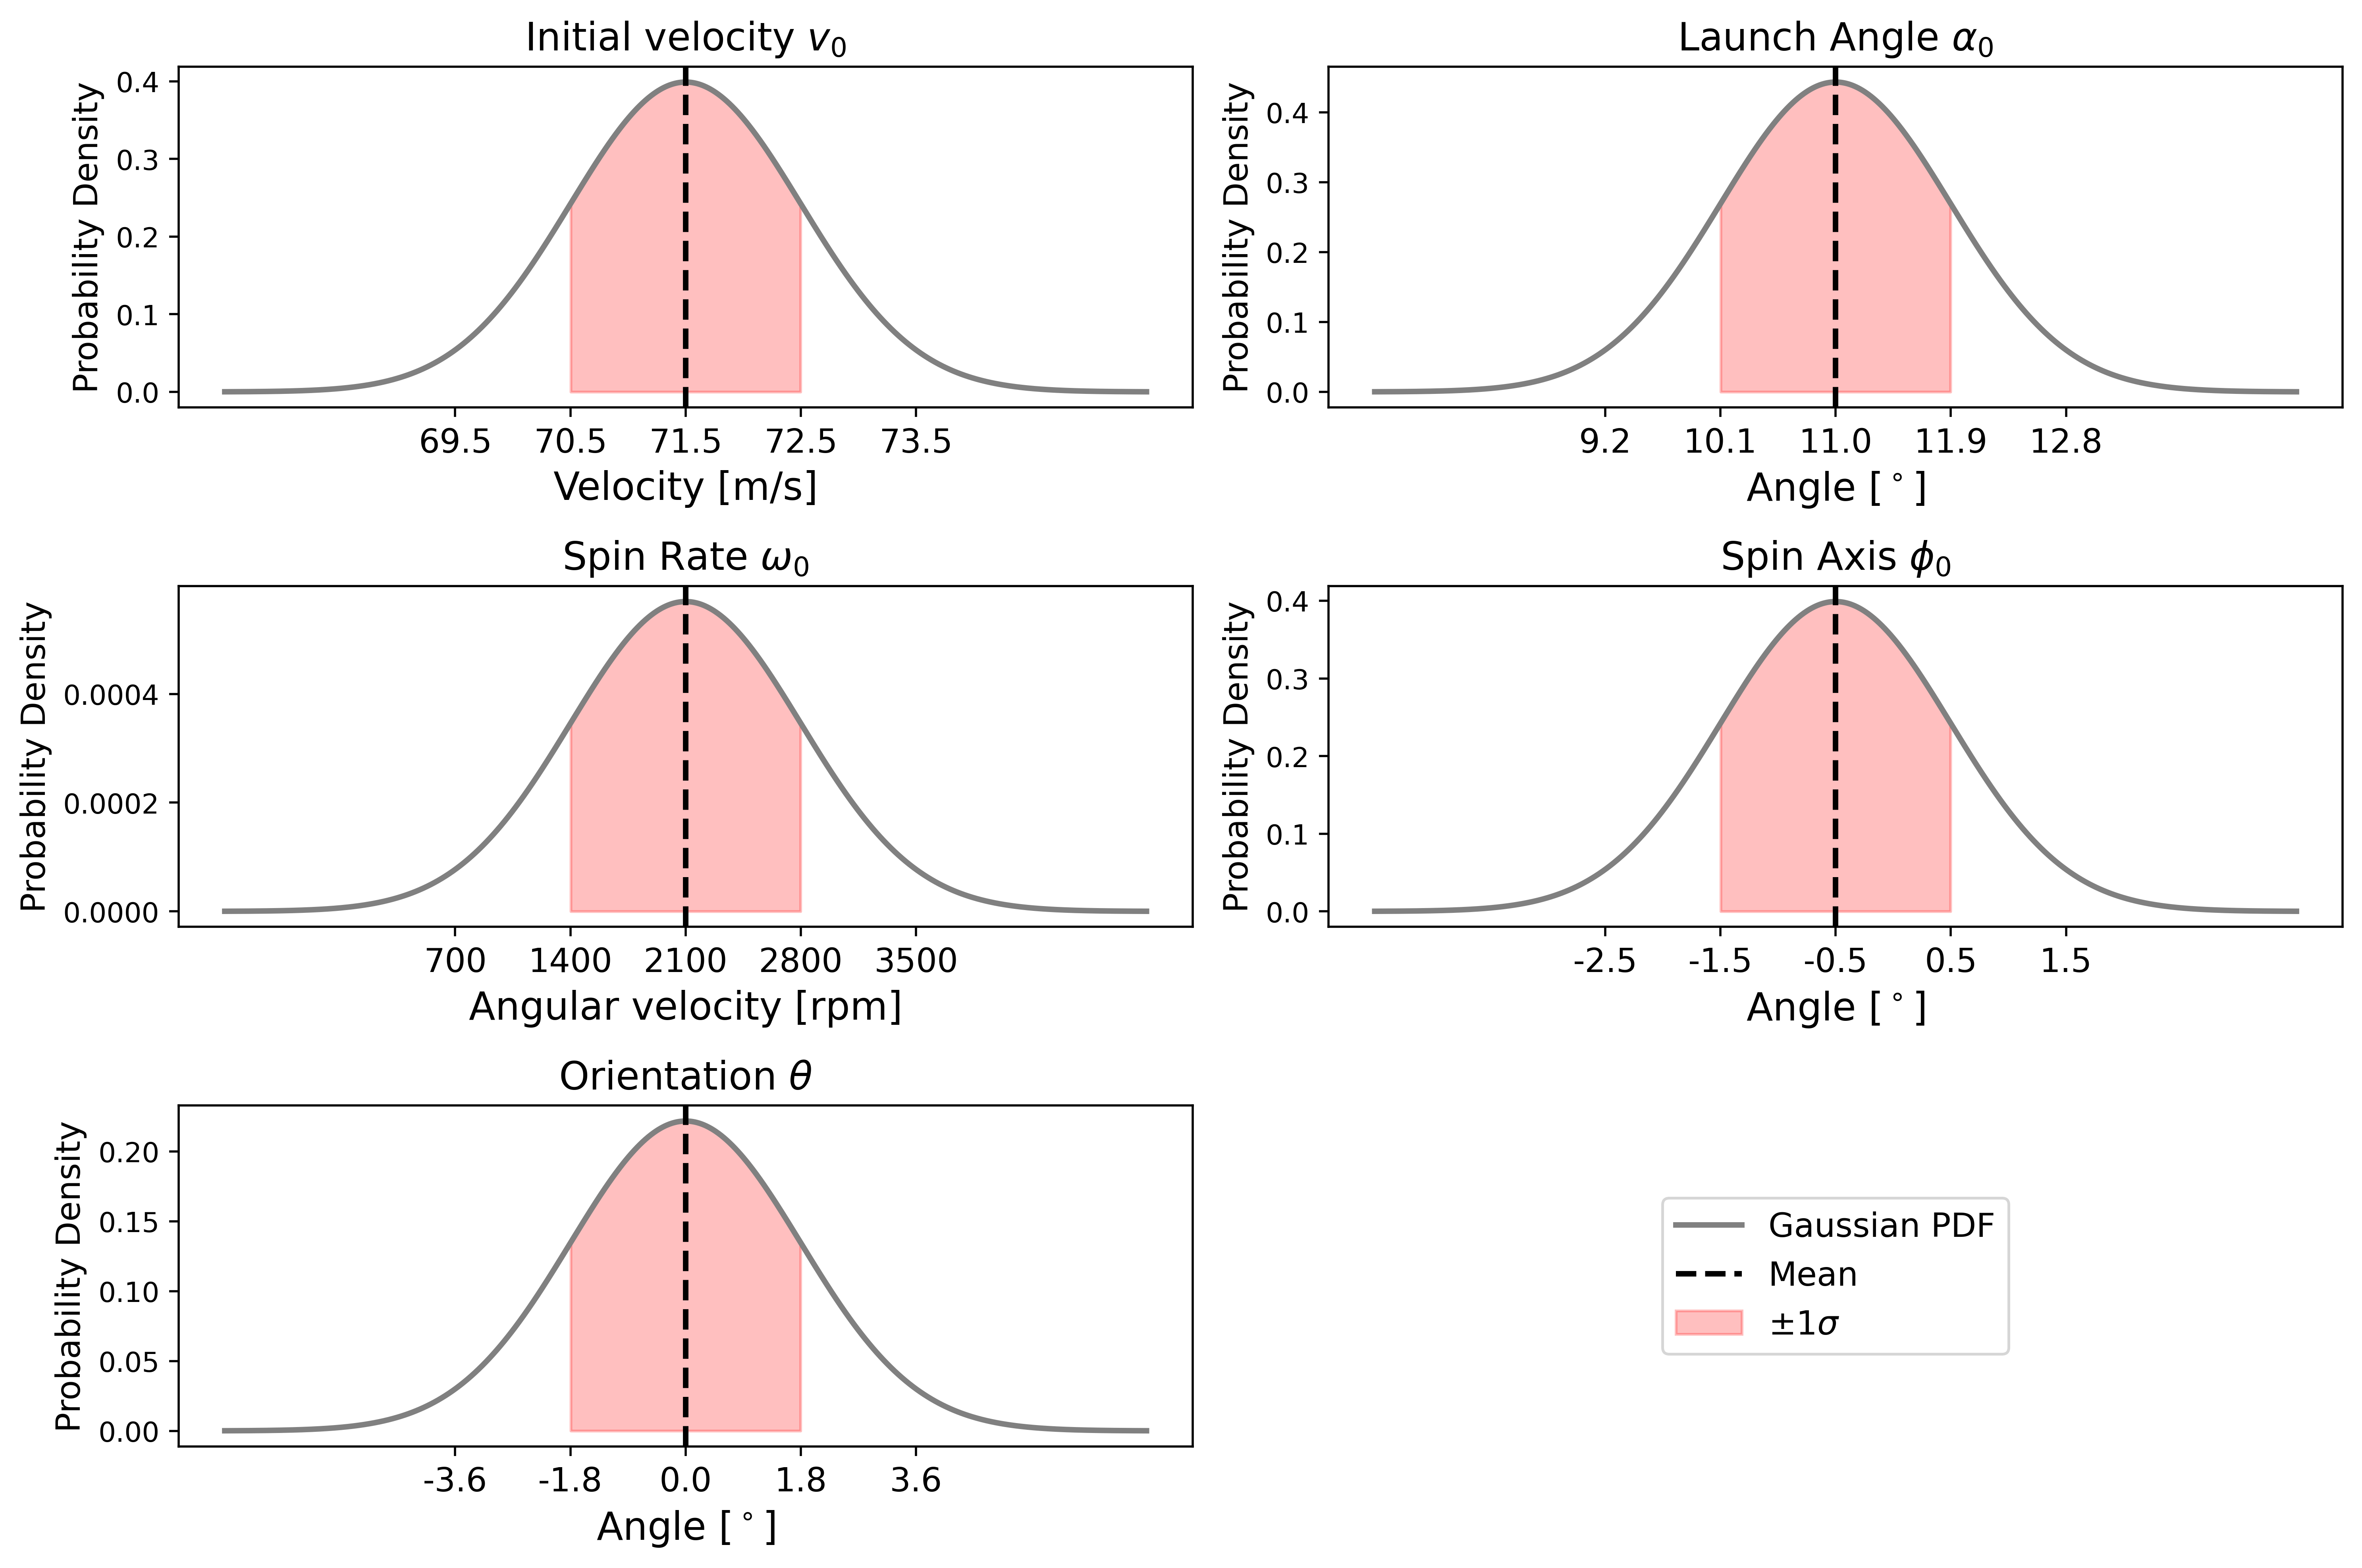

In [3]:
fig, axs = plt.subplots(3, 2, figsize=(12, 8),dpi=500)

axs = axs.flatten()

legend_handles = None

for i, param in enumerate(parameters):
    mu = anka_mean[param]
    sigma = anka_std[param]

    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

    pdf = (1 / (sigma * np.sqrt(2*np.pi))) * np.exp(
        -0.5 * ((x - mu) / sigma)**2
    )

    line_pdf, = axs[i].plot(
        x, pdf,
        color='gray',
        lw=2,
        label='Gaussian PDF'
    )

    line_mean = axs[i].axvline(
        mu,
        color='black',
        linestyle='--',
        lw=2,
        label='Mean'
    )

    mask = (x >= mu - sigma) & (x <= mu + sigma)

    patch_sigma = axs[i].fill_between(
        x[mask],
        pdf[mask],
        color='red',
        alpha=0.25,
        label=r'$\pm\sigma$'
    )

    # Tick locations
    ticks = [
        mu - 2*sigma,
        mu - sigma,
        mu,
        mu + sigma,
        mu + 2*sigma
    ]

    axs[i].set_xticks(ticks)

    axs[i].set_xticklabels([
        r'$\mu-2\sigma$',
        r'$\mu-\sigma$',
        r'$\mu$',
        r'$\mu+\sigma$',
        r'$\mu+2\sigma$'
    ])

    # Option 1: numerical labels
    axs[i].set_xticklabels(
        [f"{t:.1f}" for t in ticks],
        rotation=0,
        fontsize=12
    )
    if param == 'spin_rate': 
        axs[i].set_xticklabels(
            [f"{t:.0f}" for t in ticks],
            rotation=0,
            fontsize=12
    )
    

    # save handles once
    if legend_handles is None:
        legend_handles = [line_pdf, line_mean, patch_sigma]

    axs[i].set_title(param_names[i],fontsize=14)
    axs[i].set_ylabel('Probability Density',fontsize=12)

# x labels
axs[0].set_xlabel('Velocity [m/s]',fontsize=14)
axs[1].set_xlabel(r'Angle [$^\circ$]',fontsize=14)
axs[2].set_xlabel('Angular velocity [rpm]',fontsize=14)
axs[3].set_xlabel(r'Angle [$^\circ$]',fontsize=14)
axs[4].set_xlabel(r'Angle [$^\circ$]',fontsize=14)

# -------------------------------------------------
# Use last subplot for legend
# -------------------------------------------------
axs[5].axis('off')

axs[5].legend(
    legend_handles,
    ['Gaussian PDF', 'Mean', r'$\pm1\sigma$'],
    loc='center',
    fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()